## Perturbation experiments for ITER with TokaMaker_TORAX: Increasing impurity radiation and fueling (tungsten influx followed by increased pellet fueling)

2026-09-28 D. Fisher

This notebook first sets up an example pulse simulation using a TokaMaker and TORAX coupled workflow. The inputs are based on Budney et al. 2008 Nuclear Fusion, but are not intended to be exact or in any way an ideal ITER shot.

After establishing a standard pulse, we will apply a perturbation and analyze what effect this has on the pulse.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from OpenFUSIONToolkit.TokaMaker.pulse_design import compute_disruptivity_limits, plot_ldl_hdl_with_mode, plot_dl_combined_single_color
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

In [2]:
# Global inputs
R0 = 6.3 # m, geometric center of the device
B0 = 5.2 # T, toroidal magnetic field at center of the device
Z0 = 0.5 # m, center of ITER plasma is at +0.5 m on this grid

In [3]:
# OFT setup
tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.pulse_design import TokaMaker_TORAX
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_power_flux_fun, create_isoflux
import numpy as np
import matplotlib.pyplot as plt
import os
cwd = os.getcwd()

myOFT = OFT_env(nthreads=4)
mygs = TokaMaker(myOFT)

mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict = load_gs_mesh('ITER_mesh.h5')
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.settings.maxits=100
mygs.setup(order = 2, F0 = R0*B0)

mygs.set_coil_vsc({'VS': 1.0})

# Silence CG Solver
mygs.settings.pm = False
mygs.update_settings()

#----------------------------------------------
             ____  ____________
            / __ \/ ____/_  __/
           / / / / /_    / /
          / /_/ / __/   / /
          \____/_/     /_/

Base release:        
Development branch:  disruptivity-limits
Revision id:         6eabd40

Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    4

Linear Algebra backend: native

#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  2.859E+02
    # of points  =    4757
    # of edges   =   14156
    # of cells   =    9400
    # of boundary points =     112
    # of boundary edges  =     112
    # of boundary cells  =     112
  Resolution statistics:
    hmin =  9.924E-03
    hrms =  2.826E-01
    hmax =  8.466E-01
  Surface grounded at vertex     870


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux 

In [4]:
# Set coil bounds
coil_bounds = {key: [-50.E6, 50.E6] for key in mygs.coil_sets}
mygs.set_coil_bounds(coil_bounds)

# function to build regularization terms for coil currents for initial equilibrium solves.
def build_min_norm_coil_reg(mygs):
    """Mild regularization to keep currents reasonable without targeting specific coils."""
    reg_terms = []
    for name in mygs.coil_sets:
        if name.startswith('CS'):
            weight = 2.E-2 if name.startswith('CS1') else 1.E-2
            reg_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=weight))
        elif name.startswith('PF'):
            reg_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=1.E-2))
        elif name.startswith('VS'):
            reg_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=1.E-2))
    reg_terms.append(mygs.coil_reg_term({'#VSC': 1.0}, target=0.0, weight=1.E2))
    mygs.set_coil_reg(reg_terms=reg_terms)

In [5]:
# Make initial FF' and p' profiles for initial equilibria
ffp_prof = create_power_flux_fun(40,1.5,2.0)
pp_prof = create_power_flux_fun(40,4.0,1.0)
mygs.set_profiles(ffp_prof=ffp_prof,pp_prof=pp_prof)

In [6]:
# Make Ip and pax targets
Ip_targets = [1.5e6, 5e6, 15e6, 15e6, 1.5e6]
# pax = pressure on axis
# pax targets calculated from Budney et al. 2008 plots
pax_initial = 2 * 1e19 * 1e3 * 1.602e-19
pax_final = 2 * 1e20 * 12.5e3 * 1.603e-19
pax_targets = [pax_initial, 0.3*pax_initial, pax_final, pax_final, pax_initial]

In [7]:
# Set shape targets
a = [1, 2, 2, 2, 1]
kappa = [1, 1.3, 1.8, 1.8, 1]
delta = [0, 0, 0, 0, 0]
diverted = [False, False, True, True, False]
x_points = np.array([[5.125, -3.4],])
diverted_isoflux_pts =np.array([
    [ 8.20,  0.41],
    [ 8.06,  1.46],
    [ 7.51,  2.62],
    [ 6.14,  3.78],
    [ 5.1 ,  3.72],
    [ 4.51,  3.02],
    [ 4.26,  1.33],
    [ 4.28,  0.08],
    [ 4.49, -1.34],
    [ 7.28, -1.89],
    [ 8.00, -0.68]
])
target_psi_lcfs = [+20, +13, +10, 0, +5] # Wb/rad targets for LCFS flux. Only the first value is used by TORAX, the others are overwritten after the first TORAX run.

In [8]:
# Produce initial equilibria
psi_lcfs_results = []

for idx in range(len(a)):
    psi_lcfs_target = target_psi_lcfs[idx]

    if diverted[idx]:  # Flattop (mid-swing)
        R = R0
        mygs.set_saddle_constraints(x_points)
        mygs.set_isoflux_constraints(diverted_isoflux_pts)
        psi_lcfs_weight = 10
        targets = np.full(diverted_isoflux_pts.shape[0], psi_lcfs_target)
        weights = np.full(diverted_isoflux_pts.shape[0], psi_lcfs_weight)
        mygs.set_flux(diverted_isoflux_pts, targets, weights=weights)
    else:  # Ramp-up/down (pre-charged)
        R = 3.9 + a[idx]
        isoflux_pts = create_isoflux(20, R, Z0, a[idx], kappa[idx], delta[idx])
        mygs.set_isoflux_constraints(isoflux_pts)
        # set_flux_target_on_lcfs(mygs, isoflux_pts, psi_lcfs_target, weight=5.0)
        # build_coil_reg(mygs, cs_precharge_targets) # sets coil targets and regularization depending on phase
        psi_lcfs_weight = 10
        targets = np.full(isoflux_pts.shape[0], psi_lcfs_target)
        weights = np.full(isoflux_pts.shape[0], psi_lcfs_weight)
        mygs.set_flux(isoflux_pts, targets, weights=weights)

    build_min_norm_coil_reg(mygs)
    mygs.set_targets(Ip=Ip_targets[idx], pax=pax_targets[idx])

    mygs.init_psi(R, Z0, a[idx], kappa[idx], delta[idx])
    equil_object = mygs.solve()

    stats = mygs.get_stats()
    psi_lcfs = mygs.psi_bounds[0]
    psi_lcfs_results.append(psi_lcfs)
    coil_currents, _ = mygs.get_coil_currents()

    eqdsk_name = os.path.join(cwd, f'i={idx}.eqdsk')
    mygs.save_eqdsk(eqdsk_name, cocos=2, nr=500, nz=500) # saving at extremely high resolution to avoid issues with contour tracing package used by TORAX, only necessary for initial eqdkss, could possibly be lowered

/var/folders/0c/497qwkps0n92lm8mgp_t18800000gn/T/ipykernel_61988/4242415327.py:24: DeprecationWarning: `set_flux()` is deprecated, use `set_psi_constraints()` instead. This function will be removed in a future version.
  mygs.set_flux(isoflux_pts, targets, weights=weights)


Saving gEQDSK: /Users/d22fish/Documents/7FusionResearch/Software/OpenFUSIONToolkit/oft-repo/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/TokaMaker_TORAX/Plasma_Limits/i=0.eqdsk
 Using COCOS=2...
Saving gEQDSK: /Users/d22fish/Documents/7FusionResearch/Software/OpenFUSIONToolkit/oft-repo/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/TokaMaker_TORAX/Plasma_Limits/i=1.eqdsk
 Using COCOS=2...


/var/folders/0c/497qwkps0n92lm8mgp_t18800000gn/T/ipykernel_61988/4242415327.py:14: DeprecationWarning: `set_flux()` is deprecated, use `set_psi_constraints()` instead. This function will be removed in a future version.
  mygs.set_flux(diverted_isoflux_pts, targets, weights=weights)


Saving gEQDSK: /Users/d22fish/Documents/7FusionResearch/Software/OpenFUSIONToolkit/oft-repo/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/TokaMaker_TORAX/Plasma_Limits/i=2.eqdsk
 Using COCOS=2...
Saving gEQDSK: /Users/d22fish/Documents/7FusionResearch/Software/OpenFUSIONToolkit/oft-repo/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/TokaMaker_TORAX/Plasma_Limits/i=3.eqdsk
 Using COCOS=2...
Saving gEQDSK: /Users/d22fish/Documents/7FusionResearch/Software/OpenFUSIONToolkit/oft-repo/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/TokaMaker_TORAX/Plasma_Limits/i=4.eqdsk
 Using COCOS=2...


In [9]:

eqdsk_list = [os.path.join(cwd, 'i=0.eqdsk'),  # use initial eqdsk to start
              os.path.join(cwd, 'i=1.eqdsk'),  
              os.path.join(cwd, 'i=2.eqdsk'),  # start of flattop
              os.path.join(cwd, 'i=3.eqdsk'),  # end of flattop
              os.path.join(cwd, 'i=4.eqdsk')]  # use initial eqdsk as end of pulse

eqtimes = [0, 30, 80, 500, 600] # times corresponding to each initial eqdsk


t_final = 600
tmtx = TokaMaker_TORAX(
    t_init = 0,
    t_final = t_final,
    tx_dt = 1, # s, TORAX time step 
    eqtimes = eqtimes,
    g_eqdsk_arr = eqdsk_list,
    last_surface_factor = 0.99,
    tm_times = np.linspace(0, t_final, 25), # the times at which TokaMaker will solve equilibria
    tokamaker_obj = mygs, # passes existing OFT environment to TokaMaker_TORAX
)

In [10]:
# Set TORAX Grid, 51 points evenly spaced in rho_toroidal space (TORAX radial coordinate).
tmtx.set_TORAX_grid(grid_type='n_rho', grid=51)

In [11]:
# Heating (Budney 2008 NF: ~33 MW NBI + ~20 MW ECRH at flattop = ~53 MW total)
# ECRH-assisted startup: ECRH on early in current ramp to raise Te, reduce Vloop.

# ECRH: on during ramp-up for assisted startup, continues through flattop and partway into rampdown
ecrh_powers = {
    0:    0,
    10:   0,
    50:   20.0E6,    # ECRH-assisted startup (Budney 2008: ~20 MW during ramp-up)
    80:   20.0E6,    # L-H transition; ECRH stays at 20 MW
    450:  20.0E6,    # End of flattop
    500:  15.0E6,    # Start rampdown
    520:  10.0E6,
    540:  5.0E6,
    560:  0,
    600:  0,
}

# NBI: turns on at L-H transition when plasma is sufficiently dense (Budney 2008: ~33 MW)
generic_powers = {
    0:    0,
    79:   0,
    80:   33.0E6,    # NBI on at L-H transition
    450:  33.0E6,    # End of flattop
    500:  15.0E6,    # Start rampdown
    520:  10.0E6,
    540:  7.0E6,
    560:  4.0E6,
    580:  2.0E6,
    600:  0,
}
tmtx.set_heating(generic_heat=generic_powers, generic_heat_loc=0.25, nbi_current=True, ecrh=ecrh_powers, ecrh_loc=0.35)

tmtx.set_fueling(gas_puff_S_total=1e22, gas_puff_decay_length=0.05, pellet_deposition_location=0.8, pellet_width=0.1, pellet_S_total={0: 0, 90: 5e21, 450: 5e21, 451: 0}) # estimations based on budney2008

In [12]:
# Build initial kinetic profiles
n_sample = 25
psi_sample = np.linspace(0.0, 1.0, n_sample)

def array_to_profile_dict(profile_array, psi_grid=None):
    """Convert 1D profile array to TORAX format {psi: value}"""
    if psi_grid is None:
        psi_grid = np.linspace(0.0, 1.0, len(profile_array))
    return {float(psi): float(val) for psi, val in zip(psi_grid, profile_array)}

# Initial L-mode profiles at t=0, will be relaxed during initial relax loop
ne_init = np.array([3.00000000e+19, 2.72795206e+19, 2.48786856e+19, 2.27599203e+19,
       2.08902740e+19, 1.92402147e+19, 1.77840567e+19, 1.64989820e+19,
       1.53648493e+19, 1.43640818e+19, 1.34808146e+19, 1.27014059e+19,
       1.20134100e+19, 1.14064701e+19, 1.08707306e+19, 1.03979586e+19,
       9.98080158e+18, 9.61263085e+18, 9.28769440e+18, 9.00095433e+18,
       8.74788171e+18, 8.52450318e+18, 8.32749199e+18, 8.15354792e+18,
       8.00000000e+18])
Te_init = np.array([1.5       , 1.32687858, 1.17409817, 1.03926765, 0.92029017,
       0.81528639, 0.72262179, 0.64084431, 0.56867223, 0.50498703,
       0.44877911, 0.39918038, 0.35539882, 0.31677537, 0.28268285,
       0.25259736, 0.22605101, 0.20262196, 0.18194419, 0.16369709,
       0.14759247, 0.13337748, 0.1208404 , 0.10977123, 0.1       ])

# Initial profiles only (t=0); evolve=True so TORAX handles time evolution
ne = {0.0: array_to_profile_dict(ne_init, psi_sample)}
Te = {0.0: array_to_profile_dict(Te_init, psi_sample)}

# Initial kinetic profiles and edge boundary conditions
tmtx.set_ne(ne, right_bc={0: ne_init[-1], 80: 2e19, 500: 2e19, 600: .5e19})
tmtx.set_Te(Te, right_bc=0.1)
tmtx.set_Ti(Te, right_bc=0.1)

# Pedestal: H-mode pedestal-top targets. TORAX's L/H formation model decides when they are
# applied (P_SOL > P_LH) and removed (P_SOL < 0.8*P_LH), ramping over transition_time.
ne_ped_val = .9e20   # m^-3
Te_ped_val = 3.0     # keV, used for both Te and Ti

tmtx.set_pedestal(config_mode='ADAPTIVE_SOURCE',
                  ped_height_Te=Te_ped_val,
                  ped_height_Ti=Te_ped_val,
                  ped_height_ne=ne_ped_val,
                  ped_top=0.9,                     # rho_tor of the pedestal top
                  transition_time=10.0,            # s, L->H and H->L ramp duration
                  formation_model='martin_scaling')

In [13]:
# Misc final setup

tmtx.set_Ip({0: Ip_targets[0], 100: Ip_targets[2], 500: Ip_targets[2], 600: Ip_targets[0]})

# Plasma composition (DT fuel + Ne impurity; Zeff=1.6 sets Ne density)
tmtx.set_plasma_composition(main_ion={'D': 0.5, 'T': 0.5}, impurity='Ne', Zeff=1.6)

tmtx.set_evolve(density=True, Ti=True, Te=True, current=True)

# Diverted window: X-point target(s), and (optionally) a shape_target that overrides the
# seed-eqdsk LCFS shape targets while diverted. Here shape_target is omitted, so the shape
# is pulled from the seed equilibria as usual.
tmtx.set_diverted_shape_targets(diverted_times = (80, 500), x_point_targets = x_points, x_point_weight=100)

tmtx.set_TokaMaker_coil_reg(coil_bounds=coil_bounds, updownsym=False)

In [14]:
tmtx.fly(run_name='tmp', 
         output_mode='false', 
         max_loop=2,
         t_ave_toggle='flattop',
         t_ave_window=25,
         relax=True,
         relax_duration=5)

  Log file: /Users/d22fish/Documents/7FusionResearch/Software/OpenFUSIONToolkit/oft-repo/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/TokaMaker_TORAX/Plasma_Limits/TokaMaker_TORAX_log_tmp.log

 TokaMaker_TORAX  
 run_name = tmp | t=[0.0, 600.0] s | 25 timepoints | dt=1 s | max_loop=2

  Initial TORAX relax


Simulating (t=5.00000): 100%|██████████| 100/100 [00:05<00:00, 16.75it/s]



  Loop 1
  TORAX: running simulation...


Simulating (t=600.00000): 100%|██████████| 100/100 [00:31<00:00,  3.15it/s]


  TORAX: L->H transition at 81.44 s, H->L back-transition at 488.1 s
  TORAX: done (cflux=168.5975 Wb)
  TokaMaker: solving 25 equilibria...


...

  TORAX: running simulation...


Simulating (t=600.00000): 100%|██████████| 100/100 [00:31<00:00,  3.19it/s]


  TORAX: L->H transition at 81 s, H->L back-transition at 490 s
  TORAX: done (cflux=161.3310 Wb)
  TokaMaker: solving 25 equilibria...


  TM loop 2: 100%|██████████| 25/25 [00:52<00:00,  2.09s/solve], t=600.00s OK(L0)

  TokaMaker: 25/25 solved (cflux=161.3393 Wb)
	TM summary: 25/25 solved at tol: 1.00e-06. Levels: jphi_conv0.00: 25.
  Loop 2 result: conv_err=4.310% | TX-TM diff=0.0051% | cflux_TX=161.3310 Wb | cflux_TM=161.3393 Wb

  Max loop index (2) reached (err=4.310%)

  Loop   cflux TX [Wb]    cflux TM [Wb]    TX-TM diff %  
  ----------------------------------------------------
  1      168.5975         168.5973         0.0001        
  2      161.3310         161.3393         0.0051        

  End-of-flattop summary  (t = 500.00 s; flattop window [100.00, 500.00] s)
  --------------------------------------------------------
  Parameter                End-of-flattop      Flattop avg
  Fusion energy gained        76253.48 MJ                —
  Flux consumed                161.331 Wb                —
  P_fusion                        7.53 MW           186.68
  P_alpha                         1.51 MW            37.34
  Q                                 0.234            3.476
  H98               

## Experiment: Increase impurity radiation and fueling (tungsten influx followed by increased pellet fueling)

We now introduce a trace amount of tungsten into the existing neon impurity population, ramping up at t=200s and stepping back down at t=450s. Pellet fueling flux is increased at t=300s and also stepped down at t=450s. The neon impurity content is held constant at 0.01 throughout the pulse. Tungsten enters at a content of 1e-5. Above this concentration, TORAX crashes with a low-temperature collapse, representative of a radiative collapse. This scenario parallels how the plasma may evolve if, for example, PFCs degrade and small chunks of it are introduced into the plasma mid-pulse.

Raising pellet fueling partway through the impurity event is a basic test of whether it can offset the tungsten-driven degradation. With tungsten specified as a fixed ratio to n_e, raising density here also raises tungsten's absolute radiated power, working against benefits from the added fueling. The plots below show that the density oscillations set off by the tungsten influx smooth out and the density plateau increases with the added fueling at t=300s, but n_e, Maris density limit, and beta_N all stay below baseline for the full injection window rather than recovering.

In [15]:
# Define impurity profile for the plasma composition to incorporate tungsten and neon impurities
impurity_profile = {
    'impurity_mode': 'n_e_ratios', 
    'species': {
        'W': {
            0.0:   {0.0: 1e-8, 1.0: 1e-8},
            199.0: {0.0: 1e-8, 1.0: 1e-8},
            200.0: {0.0: 1e-5, 1.0: 1e-5}, # Above 1e-5 TORAX crashes
            449.0: {0.0: 1e-5, 1.0: 1e-5},
            450.0: {0.0: 1e-8, 1.0: 1e-8},
        }, 
        'Ne': 0.01
    },
}

# Raising pellet particle flux after tungsten impurity injection 
pellet_S_total={0: 0, 90: 5e21, 299: 5e21, 300: 2.5e22, 449: 2.5e22, 450: 5e21, 550: 0}

tmtx_w = TokaMaker_TORAX(
    t_init=0, t_final=t_final, tx_dt=1, eqtimes=eqtimes, g_eqdsk_arr=eqdsk_list,
    last_surface_factor=0.99, tm_times=np.linspace(0, t_final, 25), tokamaker_obj=mygs,
)
tmtx_w.set_TORAX_grid(grid_type='n_rho', grid=51)
tmtx_w.set_heating(generic_heat=generic_powers, generic_heat_loc=0.25, nbi_current=True, ecrh=ecrh_powers, ecrh_loc=0.35)

gas_puff_profile = {0: 1e22, 600: 1e22}
tmtx_w.set_fueling(gas_puff_S_total=gas_puff_profile, gas_puff_decay_length=0.05,
                    pellet_deposition_location=0.8, pellet_width=0.1,
                    pellet_S_total=pellet_S_total)

tmtx_w.set_ne(ne, right_bc={0: ne_init[-1], 80: 2e19, 500: 2e19, 600: .5e19})

tmtx_w.set_Te(Te, right_bc=0.1)
tmtx_w.set_Ti(Te, right_bc=0.1)
tmtx_w.set_pedestal(config_mode='ADAPTIVE_SOURCE', ped_height_Te=Te_ped_val, ped_height_Ti=Te_ped_val,
                     ped_height_ne=ne_ped_val, ped_top=0.9, transition_time=10.0, formation_model='martin_scaling')
tmtx_w.set_Ip({0: Ip_targets[0], 100: Ip_targets[2], 500: Ip_targets[2], 600: Ip_targets[0]})

tmtx_w.set_plasma_composition(main_ion={'D': 0.5, 'T': 0.5}, impurity=impurity_profile)

tmtx_w.set_evolve(density=True, Ti=True, Te=True, current=True)
tmtx_w.set_diverted_shape_targets(diverted_times=(80, 500), x_point_targets=x_points, x_point_weight=100)
tmtx_w.set_TokaMaker_coil_reg(coil_bounds=coil_bounds, updownsym=False)

tmtx_w.fly(run_name='tmp', output_mode='false', max_loop=2, t_ave_toggle='flattop',
           t_ave_window=25, relax=True, relax_duration=5)

  Log file: /Users/d22fish/Documents/7FusionResearch/Software/OpenFUSIONToolkit/oft-repo/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/TokaMaker_TORAX/Plasma_Limits/TokaMaker_TORAX_log_tmp.log

 TokaMaker_TORAX  
 run_name = tmp | t=[0.0, 600.0] s | 25 timepoints | dt=1 s | max_loop=2

  Initial TORAX relax


Simulating (t=5.00000): 100%|██████████| 100/100 [00:06<00:00, 14.83it/s]



  Loop 1
  TORAX: running simulation...


Simulating (t=600.00000): 100%|██████████| 100/100 [00:46<00:00,  2.13it/s]


  TORAX: L->H transition at 81.11 s, H->L back-transition at 199.9 s
  TORAX: done (cflux=243.5360 Wb)
  TokaMaker: solving 25 equilibria...


...

  TORAX: running simulation...


Simulating (t=600.00000): 100%|██████████| 100/100 [00:42<00:00,  2.36it/s]


  TORAX: L->H transition at 80.67 s, H->L back-transition at 201 s
  TORAX: done (cflux=228.8387 Wb)
  TokaMaker: solving 25 equilibria...


  TM loop 2: 100%|██████████| 25/25 [01:35<00:00,  3.81s/solve], t=600.00s OK(L0)

  TokaMaker: 25/25 solved (cflux=228.8481 Wb)
	TM summary: 25/25 solved at tol: 1.00e-06. Levels: jphi_conv0.00: 22, jphi_conv0.50: 3.
  Loop 2 result: conv_err=6.035% | TX-TM diff=0.0041% | cflux_TX=228.8387 Wb | cflux_TM=228.8481 Wb

  Max loop index (2) reached (err=6.035%)

  Loop   cflux TX [Wb]    cflux TM [Wb]    TX-TM diff %  
  ----------------------------------------------------
  1      243.5360         243.5348         0.0005        
  2      228.8387         228.8481         0.0041        

  End-of-flattop summary  (t = 500.00 s; flattop window [100.00, 500.00] s)
  --------------------------------------------------------
  Parameter                End-of-flattop      Flattop avg
  Fusion energy gained        30661.60 MJ                —
  Flux consumed                228.839 Wb                —
  P_fusion                        5.85 MW            68.77
  P_alpha                         1.17 MW            13.75
  Q                                 0.180            1.291
  

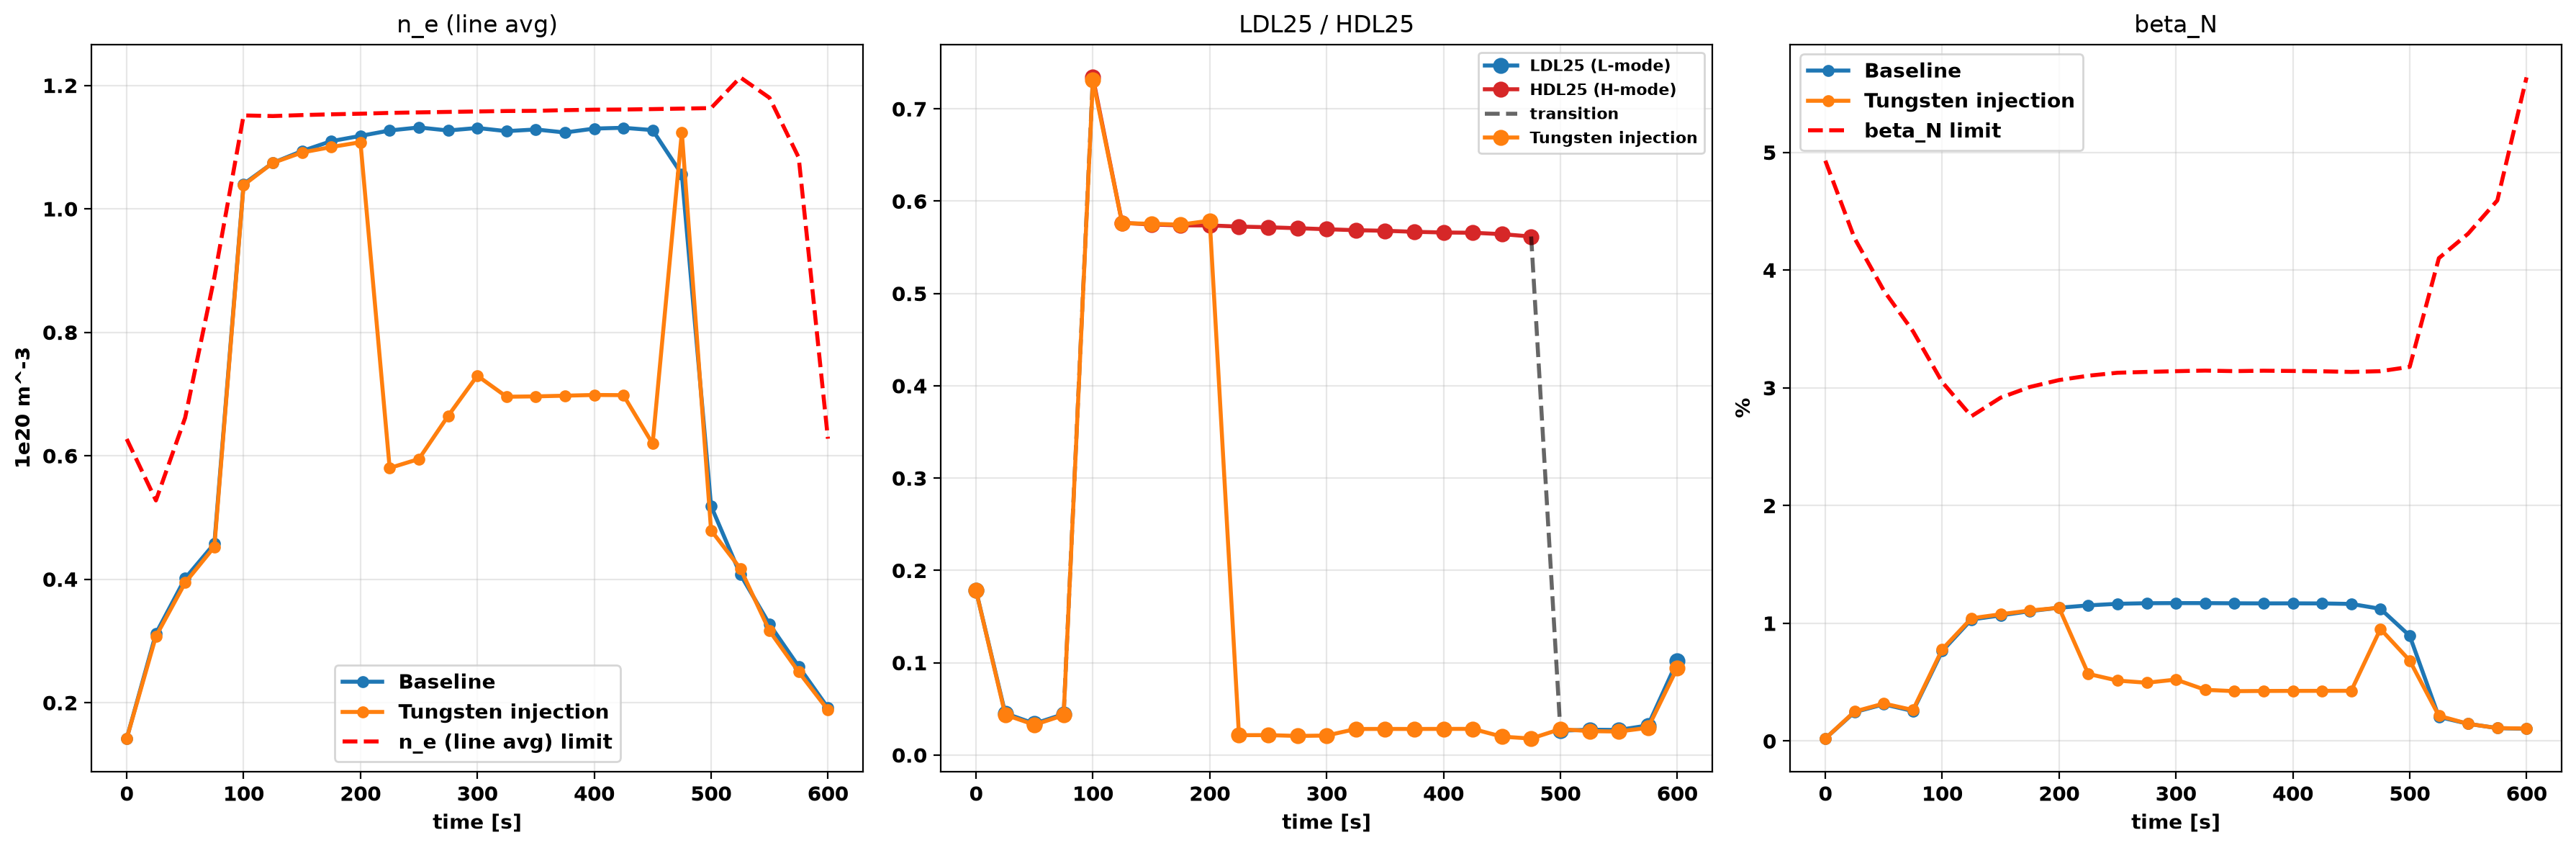

In [16]:
# Plot of baseline pulse with radiative impurity injection and increased pellet fueling perturbation 
limits_base = compute_disruptivity_limits(tmtx)
limits_pert = compute_disruptivity_limits(tmtx_w)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, key in zip([axes[0], axes[2]], ['n_e_line', 'troyon']):
    entry_base = limits_base['all_limits_units'][key]
    entry_pert = limits_pert['all_limits_units'][key]
    ax.plot(limits_base['tm_times'], entry_base['value'], 'o-', markersize=4, color='tab:blue', label='Baseline')
    ax.plot(limits_pert['tm_times'], entry_pert['value'], 'o-', markersize=4, color='tab:orange', label='Tungsten injection')
    ax.plot(limits_base['tm_times'], entry_base['limit_curve'], 'r--', label=f'{entry_base["label"]} limit')
    ax.set_title(entry_base['label'])
    ax.set_xlabel('time [s]')
    ax.set_ylabel(entry_base['units'])
    ax.legend()
    ax.grid(alpha=0.3)

plot_ldl_hdl_with_mode(limits_base, ax=axes[1])
plot_dl_combined_single_color(limits_pert, axes[1], 'tab:orange', 'Tungsten injection')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

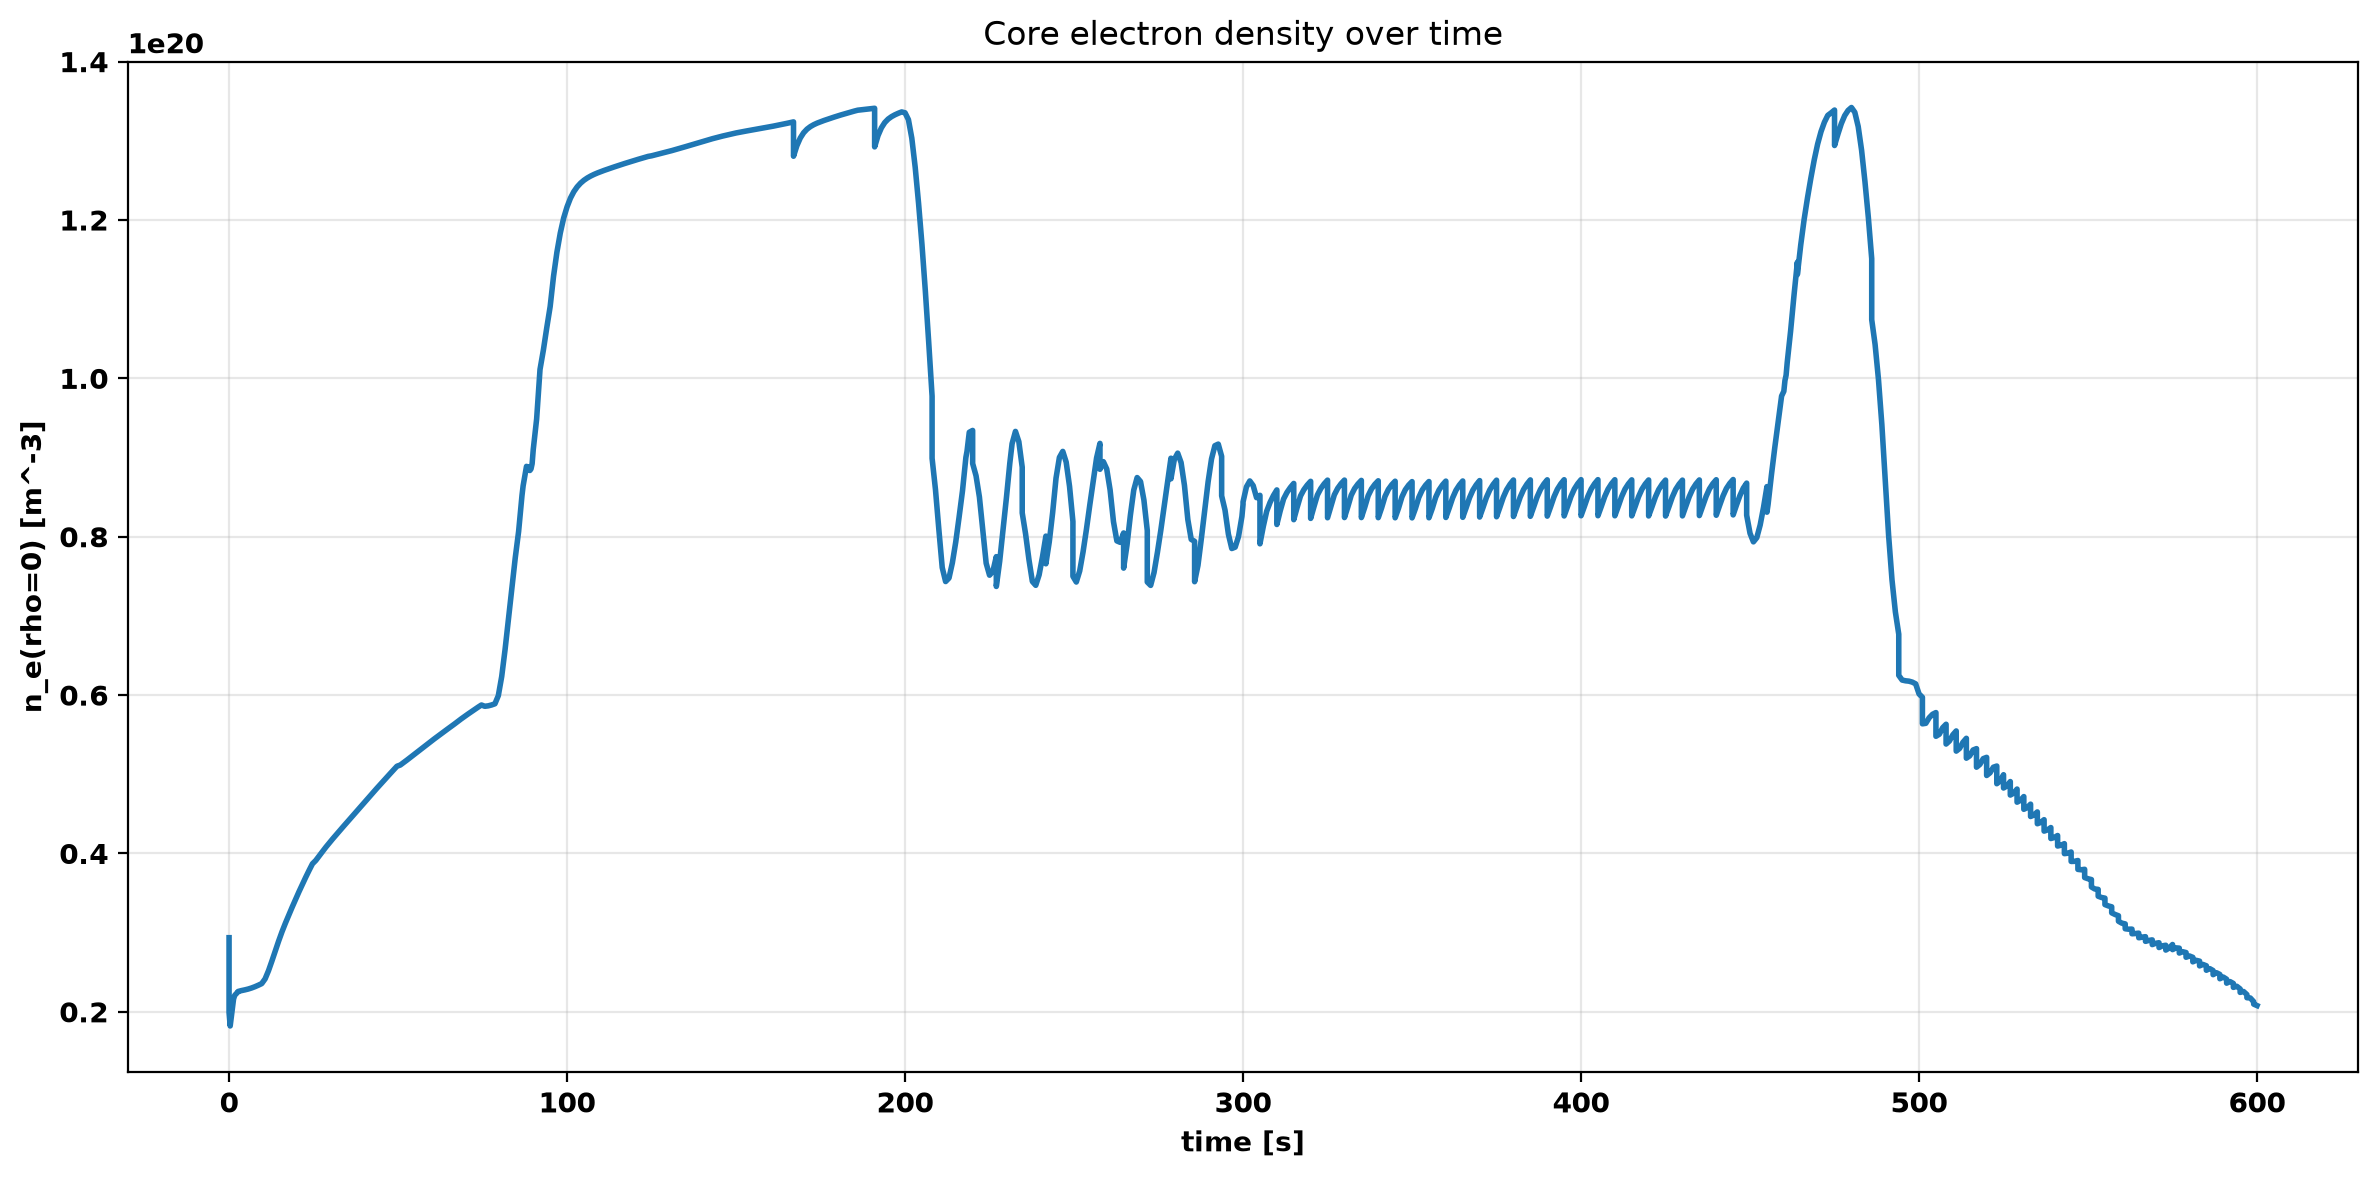

In [17]:
# Core electron density traced continuously over time
n_e_da = tmtx_w._data_tree.profiles.n_e.sel(rho_norm=0.0, method='nearest')
t_fine = n_e_da.coords['time'].to_numpy()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(t_fine, n_e_da.to_numpy())
ax.set_xlabel('time [s]')
ax.set_ylabel('n_e(rho=0) [m^-3]')
ax.set_title('Core electron density over time')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

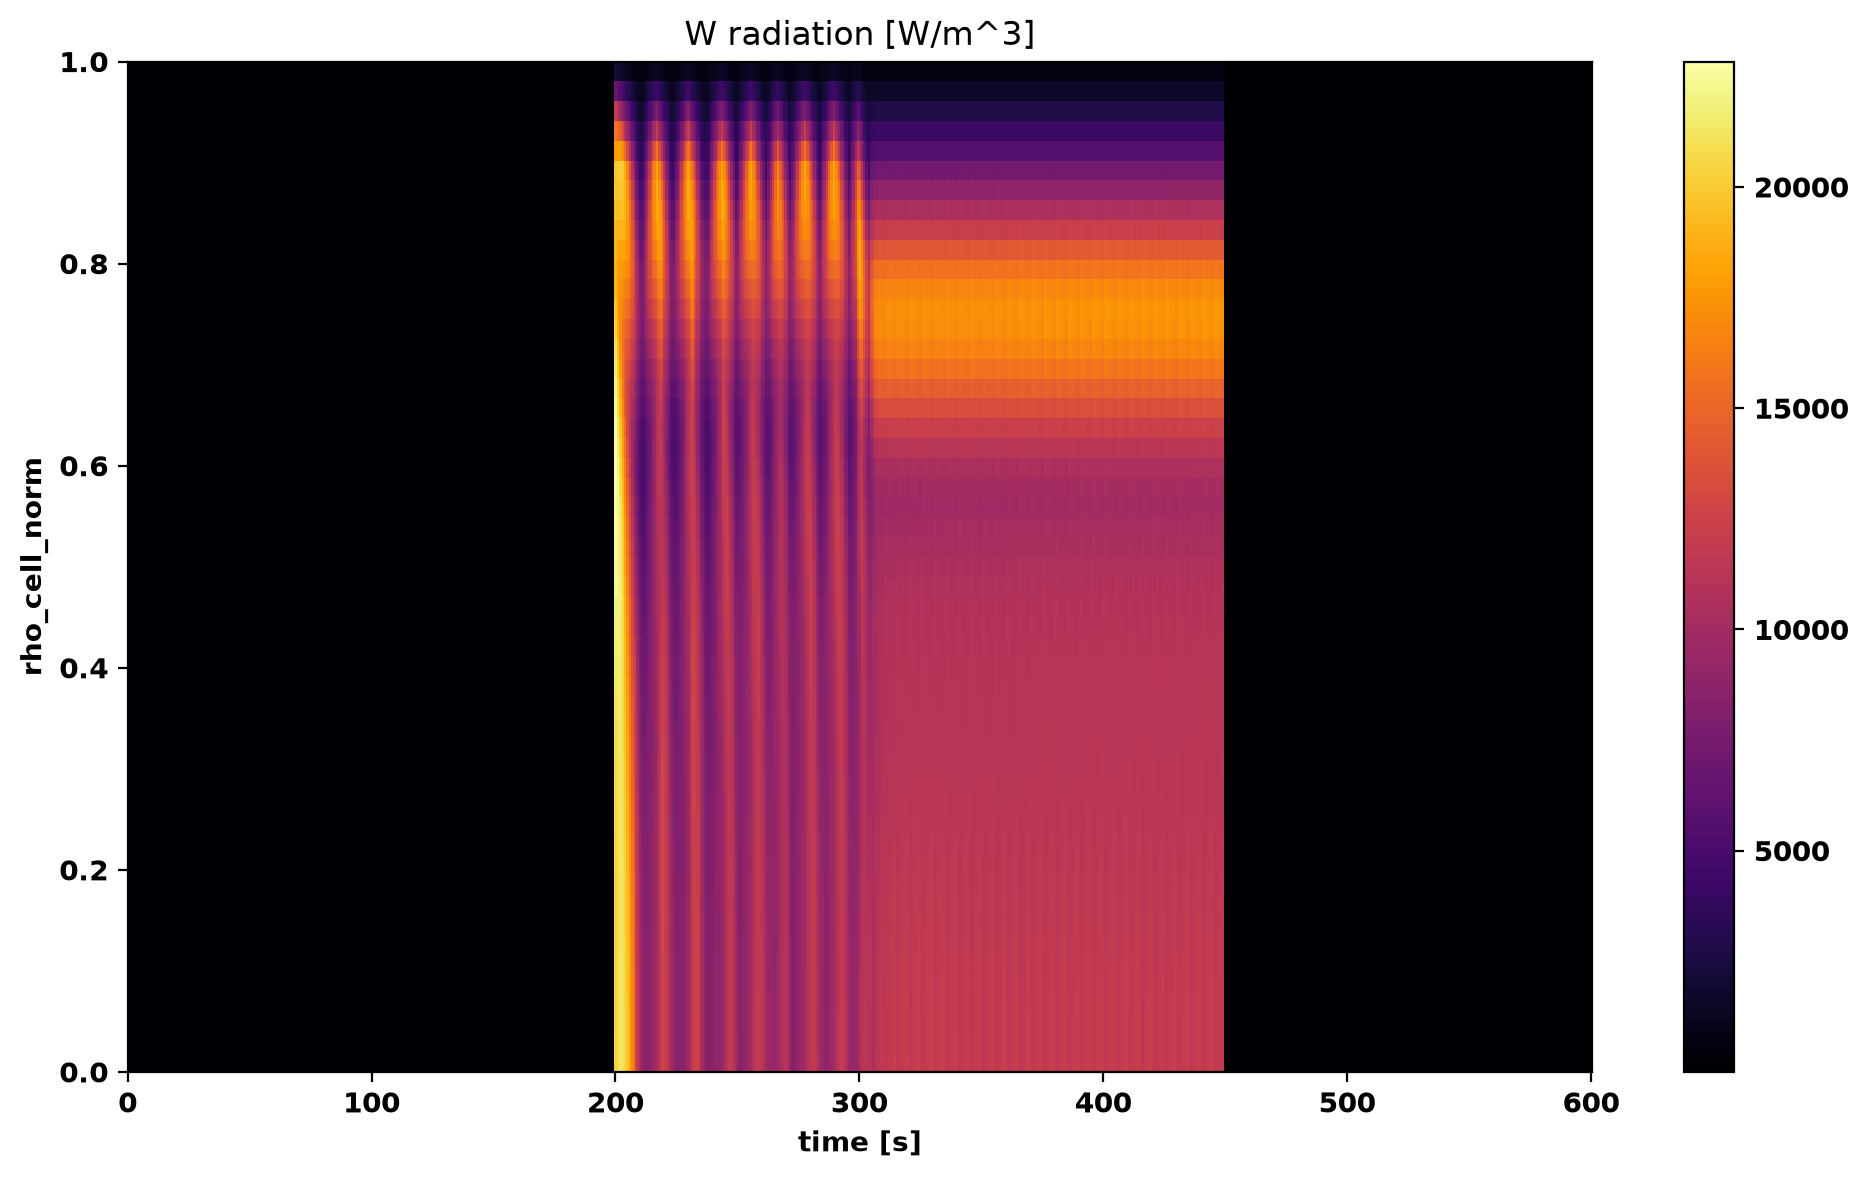

In [18]:
# Tungsten radiation profile evolution
rad = tmtx_w._data_tree.profiles.radiation_impurity_species.sel(impurity_symbol='W')
rho = rad.coords['rho_cell_norm'].to_numpy()
t_rad = rad.coords['time'].to_numpy()

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolormesh(t_rad, rho, rad.to_numpy().T, shading='auto', cmap='inferno')
ax.set_xlabel('time [s]')
ax.set_ylabel('rho_cell_norm')
ax.set_title('W radiation [W/m^3]')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

The tungsten radiation is confined to the t=200-450s injection window. The oscillatory striping from t=200-300s tracks the same density oscillations seen in the core density trace above with both settling into a steadier pattern once pellet fueling increases at t=300s. 